<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [18]:
#All needed imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

Problem 1

In [3]:
from tensorflow.keras.datasets import cifar10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)


In [8]:
# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [9]:
# Combine train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
y = np.concatenate([y_train_full, y_test], axis=0)
print("Full dataset:", X.shape, y.shape)

Full dataset: (60000, 32, 32, 3) (60000, 1)


In [10]:
# Shuffle
np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [11]:
# Split the full dateset to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = y[n_train + n_valid_and_test:]

In [12]:
# Print shapes to verify
print("Training set:   ", X_train.shape, y_train.shape)
print("Validation set: ", X_valid.shape, y_valid.shape)
print("Test set:       ", X_test.shape, y_test.shape)

Training set:    (36000, 32, 32, 3) (36000, 1)
Validation set:  (12000, 32, 32, 3) (12000, 1)
Test set:        (12000, 32, 32, 3) (12000, 1)


In [13]:
from tensorflow.keras.utils import to_categorical
num_classes = 10

# Convert to one-hot
y_train_oh = to_categorical(y_train, num_classes)
y_valid_oh   = to_categorical(y_valid, num_classes)
y_test_oh  = to_categorical(y_test, num_classes)

In [14]:
print("y_train one-hot:", y_train_oh.shape)
print("y_val one-hot:", y_valid_oh.shape)
print("y_test one-hot:", y_test_oh.shape)

y_train one-hot: (36000, 10)
y_val one-hot: (12000, 10)
y_test one-hot: (12000, 10)


In [15]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
#first layer
    layers.Conv2D(filters=16, kernel_size=(5, 5), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#second layer - retain omage size by adding padding zeros
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
#third layer - retain imagr size by adding padding zeros
    layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

#classification part
    layers.Flatten(),
    layers.Dropout(0.25),

    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [27]:
#Create a clone model of the above CNN with exactly the same initial weights.

clone_model = keras.models.clone_model(model)
clone_model.build(input_shape=(None, 32, 32, 3))

# copy same weights
clone_model.set_weights(model.get_weights())

In [28]:
# Early stopping Adam
early_stopping_adam = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [29]:
# Early stopping SGD
early_stopping_sgd = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [21]:
# Compile the original model with Adam
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
# Compile the clone model with SGD
clone_model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Train model with Adam
history_adam = model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_adam],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.7140 - loss: 0.8077 - val_accuracy: 0.6375 - val_loss: 1.0589
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7169 - loss: 0.7936 - val_accuracy: 0.6418 - val_loss: 1.0471
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7201 - loss: 0.7850 - val_accuracy: 0.6420 - val_loss: 1.0472
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7219 - loss: 0.7781 - val_accuracy: 0.6295 - val_loss: 1.0891
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7272 - loss: 0.7681 - val_accuracy: 0.6408 - val_loss: 1.0647
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7284 - loss: 0.7607 - val_accuracy: 0.6483 - val_loss: 1.0265
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.7347 - loss: 0.7466 - val_accuracy: 0.6466 - val_loss: 1.0491
Epoch 8/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 

In [31]:
# Train model with SGD
history_sgd = clone_model.fit(
    X_train, y_train_oh,
    epochs=100,
    validation_data=(X_valid, y_valid_oh),
    callbacks=[early_stopping_sgd],
    verbose=1
)

Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.7126 - loss: 0.8073 - val_accuracy: 0.6482 - val_loss: 1.0287
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7175 - loss: 0.7939 - val_accuracy: 0.6503 - val_loss: 1.0280
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7199 - loss: 0.7847 - val_accuracy: 0.6332 - val_loss: 1.0764
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7214 - loss: 0.7756 - val_accuracy: 0.6317 - val_loss: 1.0918
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7283 - loss: 0.7578 - val_accuracy: 0.6515 - val_loss: 1.0385
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7297 - loss: 0.7547 - val_accuracy: 0.6463 - val_loss: 1.0467
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7332 - loss: 0.7476 - val_accuracy: 0.6437 - val_loss: 1.0667


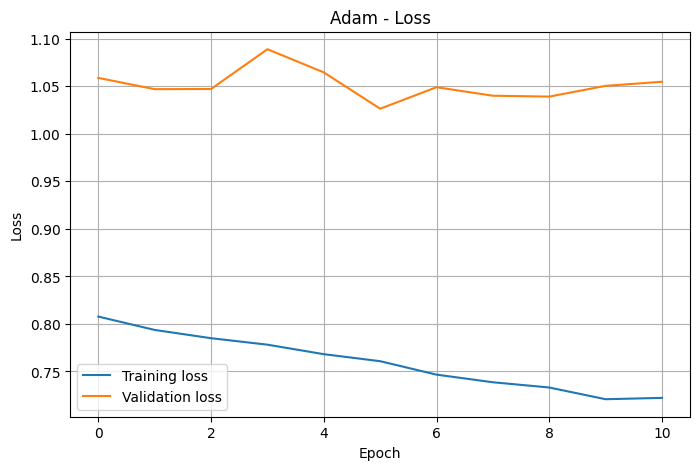

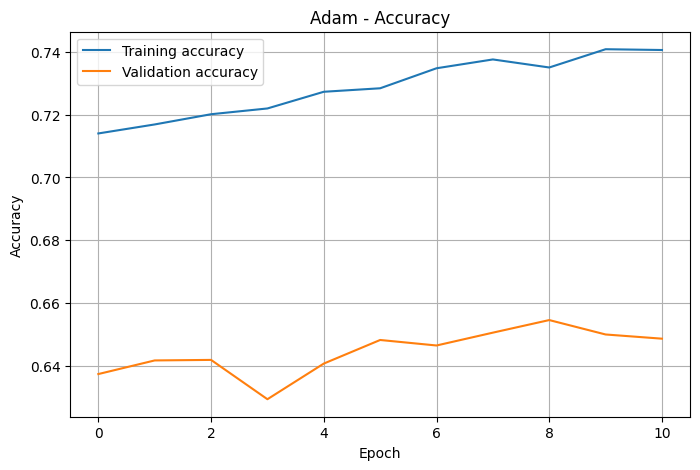

In [33]:
# Adam
plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["loss"], label="Training loss")
plt.plot(history_adam.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_adam.history["accuracy"], label="Training accuracy")
plt.plot(history_adam.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam - Accuracy")
plt.legend()
plt.grid(True)
plt.show()



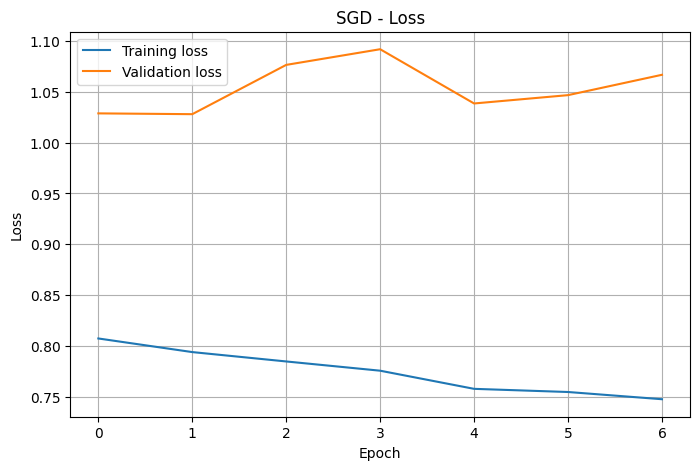

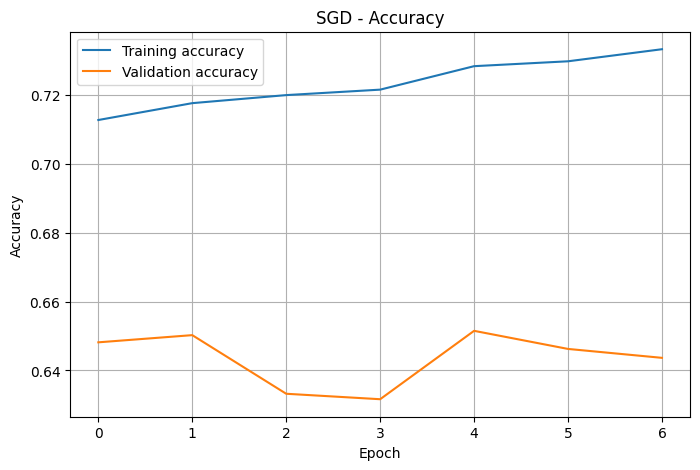

In [34]:
# SGD
plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["loss"], label="Training loss")
plt.plot(history_sgd.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_sgd.history["accuracy"], label="Training accuracy")
plt.plot(history_sgd.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SGD - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Both optimizers perform well, with decreasing loss and increasing accuracy. Adam achieves slightly better performance and continues improving for more epochs, while SGD stops earlier due to earlier validation plateau. Both models show mild overfitting, and early stopping prevents further degradation. Overall, performance is similar, with Adam slightly outperforming SGD.

In [45]:
# Validate whick optimizer is best
best_val_acc_adam = max(history_adam.history["val_accuracy"])
best_val_acc_sgd  = max(history_sgd.history["val_accuracy"])


if best_val_acc_adam >= best_val_acc_sgd:
    best = "Adam"

else:
    best = "SGD"

print("Selected best model:",best)

Selected best model: Adam


In [35]:
# Confusion matrix and accuracy on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_oh, verbose=0)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.6527500152587891


In [36]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [37]:
y_true = y_test.flatten()  # convert from (n,1) to (n,)

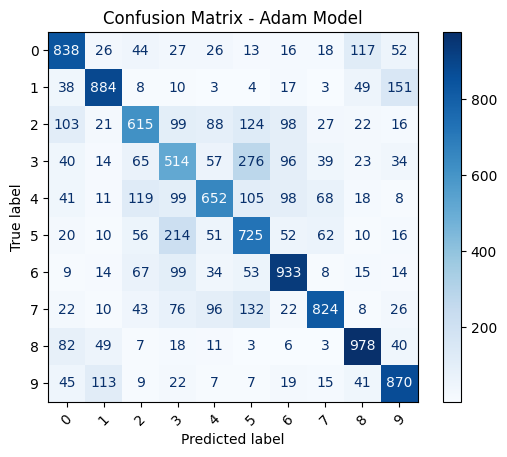

In [38]:
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Adam Model")
plt.show()

Problem 2

In [6]:
# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
temps = pd.read_csv(url, parse_dates=["Date"])

In [8]:
temps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [7]:
# Inspect the dataset
print("Shape of dataset:", temps.shape)
print("\nFirst 5 rows:")
print(temps.head())

print("\nLast 5 rows:")
print(temps.tail())

print("\nData types:")
print(temps.dtypes)

print("\nMissing values:")
print(temps.isna().sum())

Shape of dataset: (3650, 2)

First 5 rows:
        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8

Last 5 rows:
           Date  Temp
3645 1990-12-27  14.0
3646 1990-12-28  13.6
3647 1990-12-29  13.5
3648 1990-12-30  15.7
3649 1990-12-31  13.0

Data types:
Date    datetime64[ns]
Temp           float64
dtype: object

Missing values:
Date    0
Temp    0
dtype: int64


In [16]:
# Descriptive statistics
temps.describe()

,Date,Temp
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177753
min,1981-01-01 00:00:00,0.000000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.300000
std,NaN,4.071837


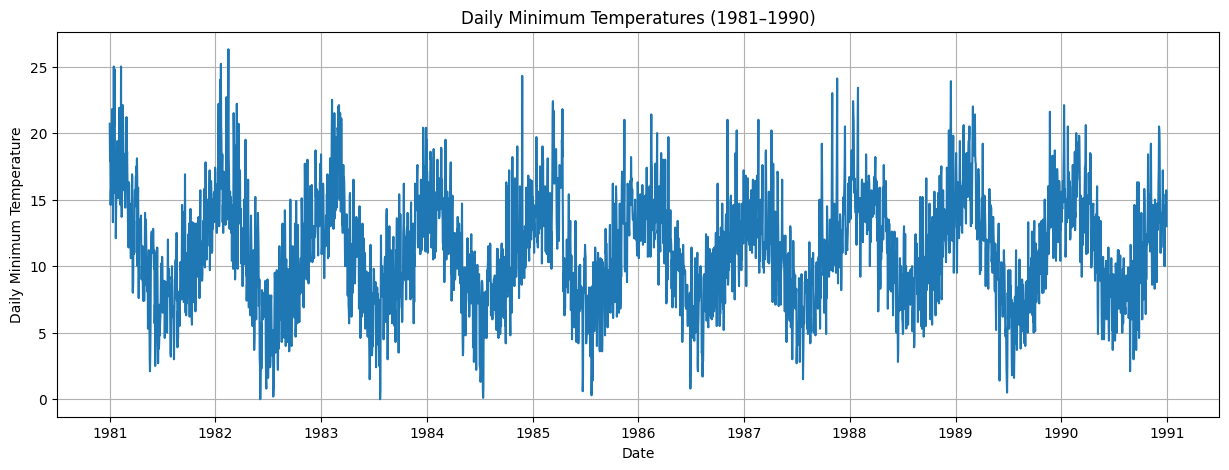

In [17]:
# Plot the entire dataset
plt.figure(figsize=(15, 5))
plt.plot(temps["Date"], temps["Temp"])
plt.xlabel("Date")
plt.ylabel("Daily Minimum Temperature")
plt.title("Daily Minimum Temperatures (1981–1990)")
plt.grid(True)
plt.show()

In [19]:
# Keep only the temperature values and convert to 2d for scaler
data = temps["Temp"].values.reshape(-1, 1)

In [23]:
# Split
n = len(data)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

# Chronological split
train = data[:train_end]
val = data[train_end:val_end]
test = data[val_end:]

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (2555, 1)
Validation shape: (547, 1)
Test shape: (548, 1)


In [25]:
# Standardization
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

In [30]:
# Define the function and create lists to store inputs and outputs
def to_windows(series, input_length=30, output_length=7):
    X = []
    y = []

#create windows with 30 inputs and 7 outputs by shifting each window by 1 day ensuring we make full windows (size 37)
#which overlap as much as possible to give
    for i in range(len(series) - input_length - output_length + 1):
        window = series[i : i + input_length + output_length]
        X.append(window[:input_length])
        y.append(window[input_length:])

    return np.array(X), np.array(y)

In [31]:
# Create the training, validation and test windows
X_train, y_train = to_windows(train_scaled, 30, 7)
X_val, y_val = to_windows(val_scaled, 30, 7)
X_test, y_test = to_windows(test_scaled, 30, 7)

# Verify the windowing was performed accurately keeping the correct split (70, 15 ,15)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



X_train shape: (2519, 30, 1)
y_train shape: (2519, 7, 1)
X_val shape: (511, 30, 1)
y_val shape: (511, 7, 1)
X_test shape: (512, 30, 1)
y_test shape: (512, 7, 1)


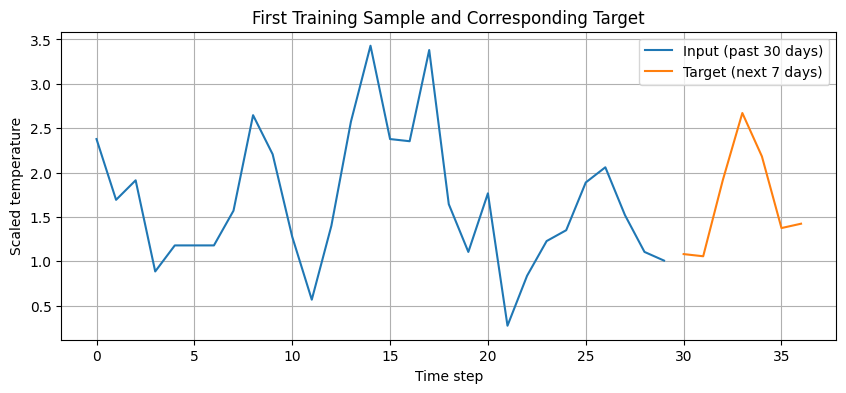

In [33]:
plt.figure(figsize=(10, 4))

plt.plot(range(30), X_train[0].flatten(), label="Input (past 30 days)")
plt.plot(range(30, 37), y_train[0].flatten(), label="Target (next 7 days)")

plt.xlabel("Time step")
plt.ylabel("Scaled temperature")
plt.title("First Training Sample and Corresponding Target")
plt.legend()
plt.grid(True)
plt.show()